# Segway PID vs LQR Simulation and Plots

This notebook is for **simulation data and graphs**. Use `view_segway_pid_lqr.py` for the live MuJoCo window.

## 1. Load packages and model

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mujoco
from scipy.linalg import solve_continuous_are

xml_path = "segway_ed.xml"

# fallback for uploaded-file environment
if not os.path.exists(xml_path):
    for p in ["/mnt/data/segway_ed.xml", "/mnt/data/segway_ed(1).xml", "/mnt/data/segway_ed(2).xml"]:
        if os.path.exists(p):
            xml_path = p
            break

print("Current folder:", os.getcwd())
print("Using XML:", xml_path)

model = mujoco.MjModel.from_xml_path(xml_path)
dt = model.opt.timestep

print("Model loaded")
print("dt =", dt)
print("nq =", model.nq, "nv =", model.nv, "nu =", model.nu)


Current folder: c:\Users\edward\OneDrive - City University of Hong Kong\uw\me569\owsbr\Ed
Using XML: segway_ed.xml
Model loaded
dt = 0.002
nq = 2 nv = 2 nu = 1


## 2. Helper functions and LQR gain

State is `[x, theta, x_dot, theta_dot]`. Control is `data.ctrl[0]`.

In [2]:
def get_state(d):
    return np.array([d.qpos[0], d.qpos[1], d.qvel[0], d.qvel[1]], dtype=float)

def set_state(model, d, state):
    d.qpos[0] = state[0]
    d.qpos[1] = state[1]
    d.qvel[0] = state[2]
    d.qvel[1] = state[3]
    mujoco.mj_forward(model, d)

def compute_lqr_gain(model, dt):
    def f_discrete(state, u):
        d = mujoco.MjData(model)
        set_state(model, d, state)
        d.ctrl[0] = float(u)
        mujoco.mj_step(model, d)
        return get_state(d)

    x_eq = np.array([0.0, 0.0, 0.0, 0.0])
    u_eq = 0.0
    eps = 1e-5

    A = np.zeros((4, 4))
    B = np.zeros((4, 1))

    for i in range(4):
        dx = np.zeros(4)
        dx[i] = eps
        A[:, i] = (f_discrete(x_eq + dx, u_eq) - f_discrete(x_eq - dx, u_eq)) / (2 * eps)

    B[:, 0] = (f_discrete(x_eq, u_eq + eps) - f_discrete(x_eq, u_eq - eps)) / (2 * eps)

    A_c = (A - np.eye(4)) / dt
    B_c = B / dt

    Q = np.diag([1.0, 500.0, 5.0, 50.0])
    R = np.array([[0.1]])

    P = solve_continuous_are(A_c, B_c, Q, R)
    K_lqr = np.linalg.inv(R) @ B_c.T @ P

    return K_lqr, x_eq

K_lqr, x_eq = compute_lqr_gain(model, dt)
print("LQR K =", K_lqr)


LQR K = [[ -3.16227794 500.26278381 205.29897171 128.83088129]]


## 3. Simulation function

This runs PID or LQR without opening the viewer. It returns a dataframe for plotting.

In [3]:
def simulate_controller(controller="PID", T=5.0, initial_state=np.array([0.0, 0.10, 0.0, 0.0]), control_sign=1.0):
    data = mujoco.MjData(model)
    set_state(model, data, initial_state)

    N = int(T / dt)

    # PID gains
    Kp = 120.0
    Ki = 0.0
    Kd = 20.0
    theta_des = 0.0
    integral = 0.0

    U_LIMIT = 100.0

    log = []

    for k in range(N):
        t = k * dt

        x = data.qpos[0]
        theta = data.qpos[1]
        x_dot = data.qvel[0]
        theta_dot = data.qvel[1]

        if controller == "PID":
            error = theta_des - theta
            integral += error * dt
            derivative = -theta_dot
            u = Kp * error + Ki * integral + Kd * derivative

        elif controller == "LQR":
            state = get_state(data)
            u = -K_lqr @ (state - x_eq)
            u = float(u[0])

        else:
            raise ValueError("controller must be 'PID' or 'LQR'")

        u = control_sign * u
        u = np.clip(u, -U_LIMIT, U_LIMIT)

        data.ctrl[0] = u

        log.append([t, x, theta, x_dot, theta_dot, u])

        mujoco.mj_step(model, data)

    df = pd.DataFrame(log, columns=["time", "x", "theta", "x_dot", "theta_dot", "control"])
    df["controller"] = controller
    return df


## 4. Run PID and LQR

If both fall immediately, change `control_sign=1.0` to `control_sign=-1.0`.

In [4]:
initial_state = np.array([
    0.0,    # x
    0.10,   # theta in rad
    0.0,    # x_dot
    0.0,    # theta_dot
])

df_pid = simulate_controller("PID", T=5.0, initial_state=initial_state, control_sign=1.0)
df_lqr = simulate_controller("LQR", T=5.0, initial_state=initial_state, control_sign=1.0)

display(df_pid.head())
display(df_lqr.head())


,time,x,theta,x_dot,theta_dot,control,controller
0,0.000,0.000000e+00,0.100000,0.000000,0.000000,-12.000000,PID
1,0.002,-2.285815e-07,0.100002,-0.000216,0.001539,-12.030976,PID
2,0.004,-8.169687e-07,0.100006,-0.000362,0.002962,-12.059966,PID
3,0.006,-1.640237e-06,0.100013,-0.000452,0.004289,-12.087372,PID
4,0.008,-2.596527e-06,0.100023,-0.000497,0.005537,-12.113521,PID


,time,x,theta,x_dot,theta_dot,control,controller
0,0.000,0.000000,0.100000,0.000000,0.000000,-50.026278,LQR
1,0.002,-0.000002,0.100000,-0.001480,-0.000056,-49.715201,LQR
2,0.004,-0.000006,0.100000,-0.002741,-0.000444,-49.406137,LQR
3,0.006,-0.000012,0.099998,-0.003822,-0.001099,-49.099056,LQR
4,0.008,-0.000021,0.099995,-0.004756,-0.001968,-48.793936,LQR


## 5. Plot PID vs LQR performance

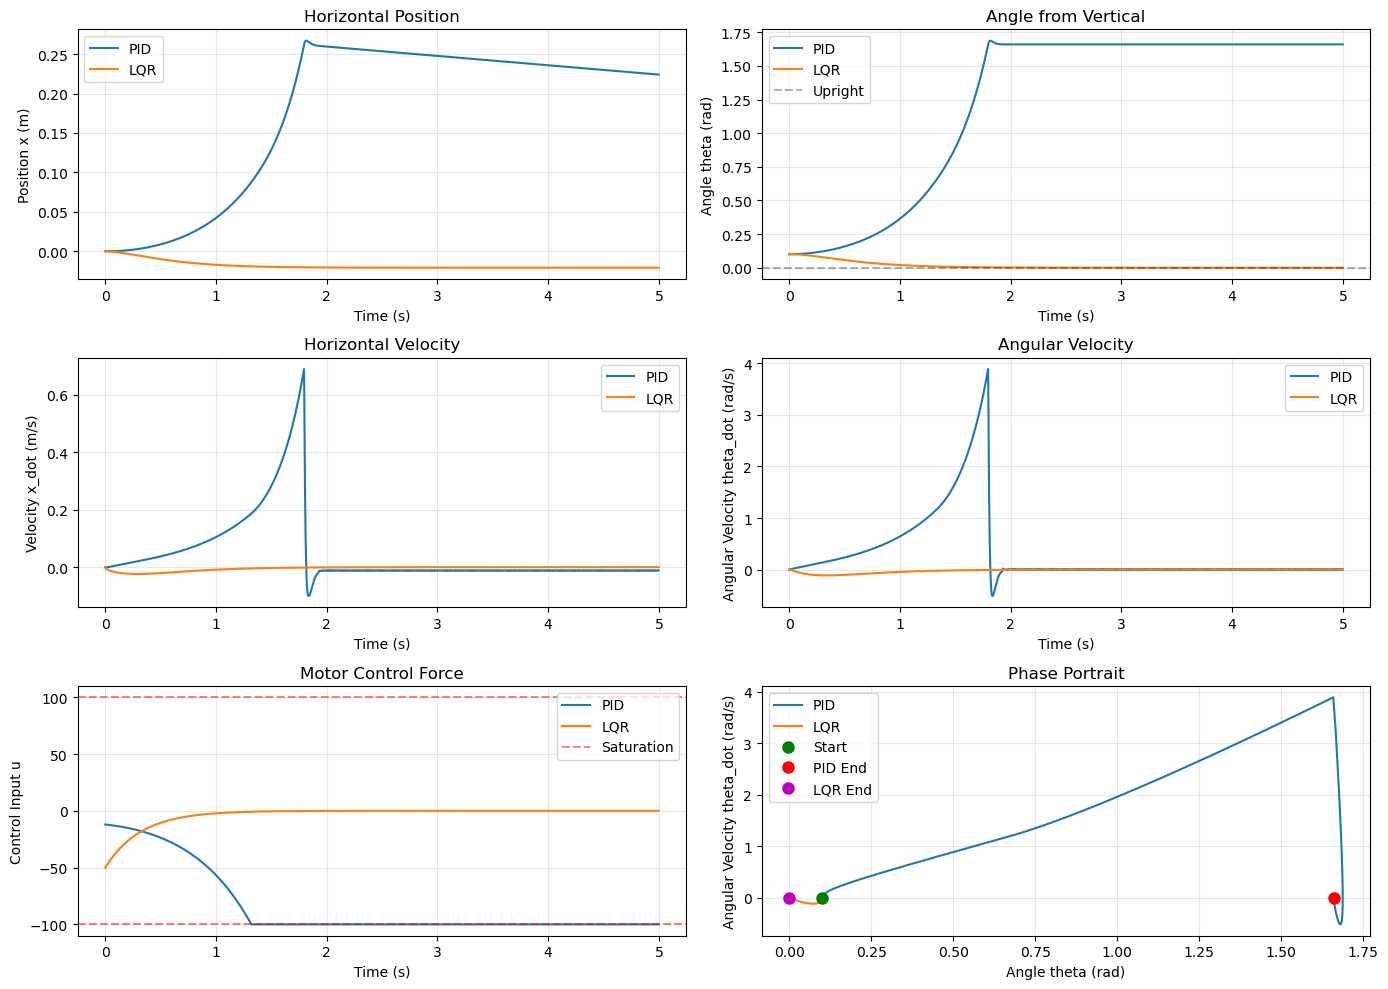

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

axes[0, 0].plot(df_pid["time"], df_pid["x"], label="PID")
axes[0, 0].plot(df_lqr["time"], df_lqr["x"], label="LQR")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("Position x (m)")
axes[0, 0].set_title("Horizontal Position")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(df_pid["time"], df_pid["theta"], label="PID")
axes[0, 1].plot(df_lqr["time"], df_lqr["theta"], label="LQR")
axes[0, 1].axhline(y=0, color="k", linestyle="--", alpha=0.3, label="Upright")
axes[0, 1].set_xlabel("Time (s)")
axes[0, 1].set_ylabel("Angle theta (rad)")
axes[0, 1].set_title("Angle from Vertical")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[1, 0].plot(df_pid["time"], df_pid["x_dot"], label="PID")
axes[1, 0].plot(df_lqr["time"], df_lqr["x_dot"], label="LQR")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Velocity x_dot (m/s)")
axes[1, 0].set_title("Horizontal Velocity")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(df_pid["time"], df_pid["theta_dot"], label="PID")
axes[1, 1].plot(df_lqr["time"], df_lqr["theta_dot"], label="LQR")
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].set_ylabel("Angular Velocity theta_dot (rad/s)")
axes[1, 1].set_title("Angular Velocity")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

axes[2, 0].plot(df_pid["time"], df_pid["control"], label="PID")
axes[2, 0].plot(df_lqr["time"], df_lqr["control"], label="LQR")
axes[2, 0].axhline(y=100, color="r", linestyle="--", alpha=0.5, label="Saturation")
axes[2, 0].axhline(y=-100, color="r", linestyle="--", alpha=0.5)
axes[2, 0].set_xlabel("Time (s)")
axes[2, 0].set_ylabel("Control Input u")
axes[2, 0].set_title("Motor Control Force")
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].legend()

axes[2, 1].plot(df_pid["theta"], df_pid["theta_dot"], label="PID")
axes[2, 1].plot(df_lqr["theta"], df_lqr["theta_dot"], label="LQR")
axes[2, 1].plot(df_pid["theta"].iloc[0], df_pid["theta_dot"].iloc[0], "go", markersize=8, label="Start")
axes[2, 1].plot(df_pid["theta"].iloc[-1], df_pid["theta_dot"].iloc[-1], "ro", markersize=8, label="PID End")
axes[2, 1].plot(df_lqr["theta"].iloc[-1], df_lqr["theta_dot"].iloc[-1], "mo", markersize=8, label="LQR End")
axes[2, 1].set_xlabel("Angle theta (rad)")
axes[2, 1].set_ylabel("Angular Velocity theta_dot (rad/s)")
axes[2, 1].set_title("Phase Portrait")
axes[2, 1].grid(True, alpha=0.3)
axes[2, 1].legend()

plt.tight_layout()
plt.show()


## 6. Performance summary

In [6]:
def summarize_performance(df, name):
    max_angle = np.max(np.abs(df["theta"]))
    final_angle = df["theta"].iloc[-1]
    final_theta_dot = df["theta_dot"].iloc[-1]
    final_position = df["x"].iloc[-1]
    max_control = np.max(np.abs(df["control"]))

    threshold = 0.02
    settling_time = None

    theta_abs = np.abs(df["theta"].to_numpy())
    time = df["time"].to_numpy()

    for i in range(len(theta_abs)):
        if np.all(theta_abs[i:] < threshold):
            settling_time = time[i]
            break

    print(f"\n{name} Performance:")
    print(f"  Max angle deviation: {max_angle:.4f} rad")
    print(f"  Final angle: {final_angle:.4f} rad")
    print(f"  Final angular velocity: {final_theta_dot:.4f} rad/s")
    print(f"  Final position: {final_position:.4f} m")
    print(f"  Max control force used: {max_control:.2f}")

    if settling_time is None:
        print("  Settling time: did not settle within 0.02 rad")
    else:
        print(f"  Settling time: {settling_time:.3f} s")

summarize_performance(df_pid, "PID")
summarize_performance(df_lqr, "LQR")



PID Performance:
  Max angle deviation: 1.6878 rad
  Final angle: 1.6603 rad
  Final angular velocity: 0.0063 rad/s
  Final position: 0.2240 m
  Max control force used: 100.00
  Settling time: did not settle within 0.02 rad

LQR Performance:
  Max angle deviation: 0.1000 rad
  Final angle: -0.0003 rad
  Final angular velocity: -0.0000 rad/s
  Final position: -0.0209 m
  Max control force used: 50.03
  Settling time: 0.988 s


## What to say in your report

```text
PID directly controls the body angle error. It can balance theta, but it may allow more horizontal drift because it does not use the full state.

LQR uses the full state [x, theta, x_dot, theta_dot], so it usually gives better overall stabilization.

If the control input stays near +100 or -100, the actuator is saturated and the controller is struggling.
```
